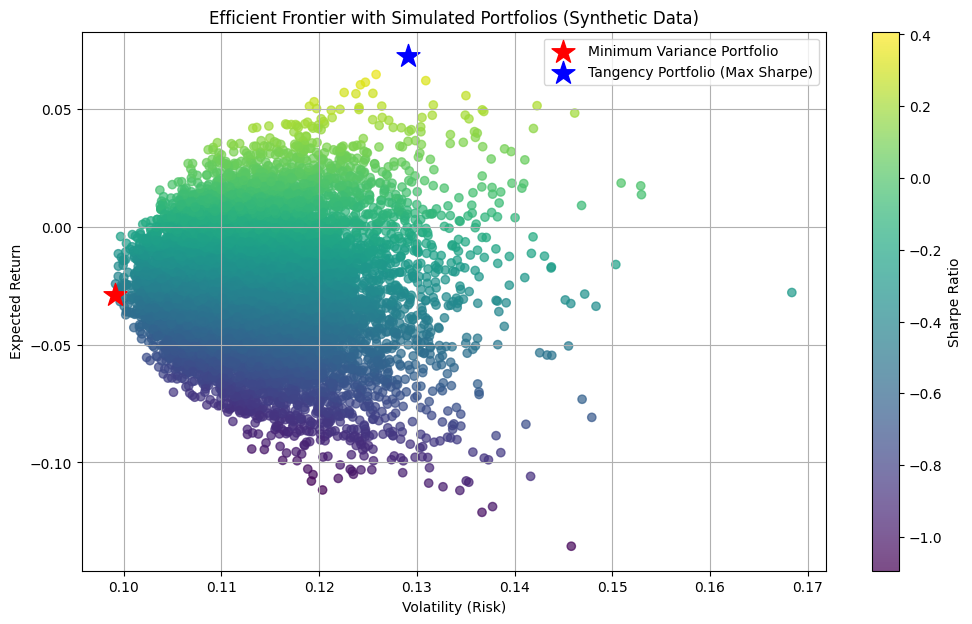

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf

# Generate synthetic data for 10 assets
np.random.seed(42)
num_assets = 10
num_years = 5
num_days = num_years * 252

# Simulate random returns
synthetic_returns = np.random.randn(num_days, num_assets) * 0.02
synthetic_prices = np.cumprod(1 + synthetic_returns, axis=0)

# Convert to DataFrame
dates = pd.date_range(start="2018-01-01", periods=num_days, freq="B")
returns = pd.DataFrame(synthetic_returns, index=dates, columns=[f"Asset_{i+1}" for i in range(num_assets)])

# Compute annualized mean returns and covariance matrix
mean_returns = returns.mean() * 252
cov_matrix = returns.cov() * 252

# Simulate random portfolios
num_portfolios = 10000
results = np.zeros((3 + num_assets, num_portfolios))

for i in range(num_portfolios):
    weights = np.random.random(num_assets)
    weights /= np.sum(weights)

    # Portfolio return and volatility
    portfolio_return = np.sum(weights * mean_returns)
    portfolio_volatility = np.sqrt(np.dot(weights.T, np.dot(cov_matrix, weights)))

    # Sharpe ratio (assuming risk-free rate = 2%)
    risk_free_rate = 0.02
    sharpe_ratio = (portfolio_return - risk_free_rate) / portfolio_volatility

    results[:, i] = [portfolio_return, portfolio_volatility, sharpe_ratio, *weights]

# Convert results into a DataFrame
columns = ["Return", "Volatility", "Sharpe Ratio"] + [f"Asset_{i+1}" for i in range(num_assets)]
portfolio_df = pd.DataFrame(results.T, columns=columns)

# Find optimal portfolios
max_sharpe_portfolio = portfolio_df.iloc[portfolio_df["Sharpe Ratio"].idxmax()]
min_vol_portfolio = portfolio_df.iloc[portfolio_df["Volatility"].idxmin()]

# Plot the Efficient Frontier
plt.figure(figsize=(12, 7))
plt.scatter(portfolio_df["Volatility"], portfolio_df["Return"], c=portfolio_df["Sharpe Ratio"], cmap="viridis", alpha=0.7)
plt.colorbar(label="Sharpe Ratio")

# Highlight the Minimum Variance Portfolio and Tangency Portfolio
plt.scatter(min_vol_portfolio["Volatility"], min_vol_portfolio["Return"], color="red", marker="*", s=300, label="Minimum Variance Portfolio")
plt.scatter(max_sharpe_portfolio["Volatility"], max_sharpe_portfolio["Return"], color="blue", marker="*", s=300, label="Tangency Portfolio (Max Sharpe)")

# Labels and title
plt.xlabel("Volatility (Risk)")
plt.ylabel("Expected Return")
plt.title("Efficient Frontier with Simulated Portfolios (Synthetic Data)")
plt.legend()
plt.grid(True)

# Show the plot
plt.show()
